In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn

from dpks import QuantMatrix
from dfmodel import DigitalFamilyBinary
from scanpy.experimental.pp import highly_variable_genes


In [2]:
def preprocess_data(raw_data, design_matrix):

    quant_matrix = QuantMatrix(
        quantification_file=raw_data[['Protein'] + [sample for sample in design_matrix['sample'].values]].copy(),
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    quant_data = quant_matrix.to_df()

    quant_data = quant_data[~((quant_data["ProteinLabel"].str.startswith("HV")) | (quant_data["ProteinLabel"].str.startswith("LV")) | quant_data["ProteinLabel"].str.startswith("KV"))]
    quant_data = quant_data[~quant_data["ProteinLabel"].str.startswith("IG")]
    quant_data = quant_data[~((quant_data["ProteinLabel"] == "HBA_HUMAN") | (quant_data["ProteinLabel"] == "HBB_HUMAN") | (quant_data["ProteinLabel"] == "HBD_HUMAN") | (quant_data["ProteinLabel"] == "HEMO_HUMAN"))]

    quant_matrix = QuantMatrix(
        quantification_file=quant_data,
        design_matrix_file=design_matrix,
        annotation_fasta_file="../0_data/2023-04-24-UP000005640.fas"
    )

    return quant_matrix

In [3]:
proteomics_data_train = pd.read_csv(
    "../0_data/proteins_train_filtered.tsv"
    , sep="\t"
)
clinical_data_train = pd.read_csv(
    "../0_data/design_matrix_train.tsv",
    sep='\t'
)
clinical_data_train['sample'] = clinical_data_train['injection']

In [8]:
import glob

feature_importance_files = glob.glob("feature_importances/*.tsv")

feature_list = []

for file in feature_importance_files:

    feature_importance_data = pd.read_csv(
        file,
        sep='\t'
    )

    feature_list.extend(
        feature_importance_data['feature'].to_list()
    )

feature_list = list(set(feature_list))

In [10]:
quant_matrix_train = preprocess_data(proteomics_data_train, design_matrix=clinical_data_train)

In [11]:
X, y = quant_matrix_train.to_ml(feature_column="ProteinLabel", label_column="sepsis_or_septic_shock", comparison=(0, 1))


In [12]:
y['label'].value_counts()

label
1    465
0    215
Name: count, dtype: int64

In [13]:
#X = X.loc[:, X.var() > X.var().median()]
protein_columns = feature_list#X.columns.to_list()

In [14]:
from sklearn.preprocessing import StandardScaler

protein_scaler = StandardScaler()
X[protein_columns] = protein_scaler.fit_transform(X[protein_columns])

In [15]:
clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "mental_status_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "crp_day1",
    "trc_emergency_department",
    "sex",
    "age",
]

continuous_clinical_columns = [
    "sao2_ambulance",
    "resp_frequency_ambulance",
    "heart_rate_ambulance",
    "syst_bp_ambulance",
    "map_ambulance",
    "temperature_ambulance",
    "crea_emergency_department",
    "bili_emergency_department",
    "trc_emergency_department",
    "crp_day1",
    "age",
    #"mental_status_ambulance",
]

categorical_clinical_columns = [
    "mental_status_ambulance",
]

In [16]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler

clinical_scaler = StandardScaler()

clinical_imputer = SimpleImputer()
sex_scaler = MinMaxScaler((0, 1))
constant_imputer = SimpleImputer(strategy="constant", fill_value=1.0)

clinical_data_train[continuous_clinical_columns] = clinical_imputer.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[["mental_status_ambulance"]] = constant_imputer.fit_transform(clinical_data_train[["mental_status_ambulance"]])

clinical_data_train[continuous_clinical_columns] = clinical_scaler.fit_transform(clinical_data_train[continuous_clinical_columns])
clinical_data_train[['sex']] = sex_scaler.fit_transform(clinical_data_train[['sex']])


In [18]:
clinical_data_train['resp_dysfunction'] =  np.where(
    clinical_data_train['sofa_resp_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_resp_day3'] > 0, 1, 0
    )
)

clinical_data_train['renal_dysfunction'] = np.where(
    clinical_data_train['sofa_renal_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_renal_day2'] > 0, 1, 0
    )
)

clinical_data_train['cardiovasc_dysfunction'] = np.where(
    clinical_data_train['sofa_cardiovasc_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cardiovasc_day3'] > 0, 1, 0
    )
)

clinical_data_train['coag_dysfunction'] = np.where(
    clinical_data_train['sofa_coag_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_coag_day3'] > 0, 1, 0
    )
)

clinical_data_train['cns_dysfunction'] = np.where(
    clinical_data_train['sofa_cns_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_cns_day3'] > 0, 1, 0
    )
)

clinical_data_train['liver_dysfunction'] = np.where(
    clinical_data_train['sofa_liver_day2'] > 0, 1, np.where(
        clinical_data_train['sofa_liver_day3'] > 0, 1, 0
    )
)

In [19]:
import anndata as ad

clinical_adata = ad.AnnData(
    X=clinical_data_train[clinical_columns],
    obs=clinical_data_train.set_index("injection")
)

protein_adata = ad.AnnData(
    X=X,
    obs=quant_matrix_train.quantitative_data.var.set_index("sample")
)

In [20]:
import muon as mu

mdata = mu.MuData(
    {
        "proteomics": protein_adata,
        "clinical": clinical_adata,
    }
)

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_

In [21]:
mu.tl.mofa(
    mdata,
    outfile="clinprot_model",
    use_var="highly_variable",
    n_factors=10
)


        #########################################################
        ###           __  __  ____  ______                    ### 
        ###          |  \/  |/ __ \|  ____/\    _             ### 
        ###          | \  / | |  | | |__ /  \ _| |_           ### 
        ###          | |\/| | |  | |  __/ /\ \_   _|          ###
        ###          | |  | | |__| | | / ____ \|_|            ###
        ###          |_|  |_|\____/|_|/_/    \_\              ###
        ###                                                   ### 
        ######################################################### 
       
 
        
Loaded view='proteomics' group='group1' with N=680 samples and D=287 features...
Loaded view='clinical' group='group1' with N=680 samples and D=13 features...


Model options:
- Automatic Relevance Determination prior on the factors: True
- Automatic Relevance Determination prior on the weights: True
- Spike-and-slab prior on the factors: False
- Spike-and-slab prior on the weig

/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/run/entry_point.py:66: SyntaxWarning: invalid escape sequence '\/'
  banner = """
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/core/utils.py:50: SyntaxWarning: invalid escape sequence '\m'
  """Diagonal of :math:`\mathrm A\mathrm B^\intercal`.
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/core/distributions/multivariate_gaussian.py:243: SyntaxWarning: invalid escape sequence '\ '
  """
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/mofapy2/core/nodes/nongaussian_nodes.py:169: SyntaxWarning: invalid escape sequence '\p'
  """
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/


Converged!



#######################
## Training finished ##
#######################


Saving model in clinprot_model...
Saved MOFA embeddings in .obsm['X_mofa'] slot and their loadings in .varm['LFs'].


In [22]:
mofa_columns = []

for i in range(mdata.obsm['X_mofa'].shape[1]):

    clinical_data_train[f"MOFA {i}"] = mdata.obsm['X_mofa'][:, i]

    mofa_columns.append(f"MOFA {i}")



In [23]:
mdata.obsm['X_mofa']

array([[-3.62918779, -1.30288684,  1.36101143, ...,  2.77719209,
         0.99678924,  0.31315439],
       [ 0.21210117, -2.41387959,  1.39085975, ..., -0.50534608,
        -1.52156575, -2.0611147 ],
       [ 1.38371938, -0.70925994,  0.71941952, ...,  0.11071762,
        -0.78810314, -0.27314907],
       ...,
       [ 3.43320941, -0.45043406,  1.95492975, ...,  1.80243257,
        -0.98857475,  3.70104165],
       [-0.17412705,  0.24341559, -0.72668387, ...,  4.18841856,
         0.5245666 ,  2.75599764],
       [ 2.74499988, -2.17695665,  1.61629251, ..., -1.30249945,
        -3.02158734, -0.26199592]])

In [24]:
import mofax as mofa

In [25]:
model = mofa.mofa_model("clinprot_model")
model

MOFA+ model: clinprot model
Samples (cells): 680
Features: 300
Groups: group1 (680)
Views: clinical (13), proteomics (287)
Factors: 10
Expectations: W, Z

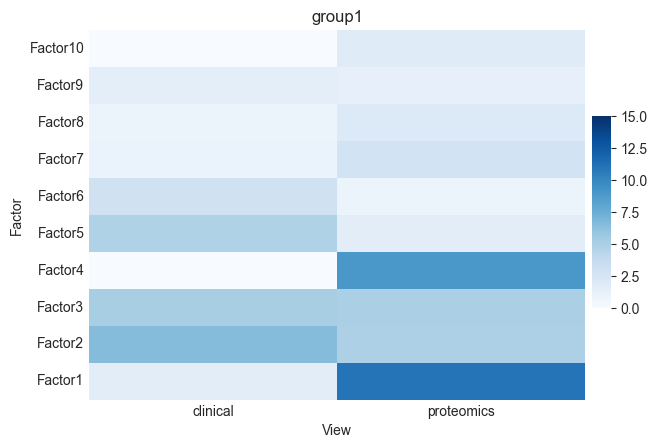

In [26]:
mofa.plot_r2(model, x='View', vmax=15)

<Axes: title={'center': 'clinical'}, xlabel='Feature weight'>

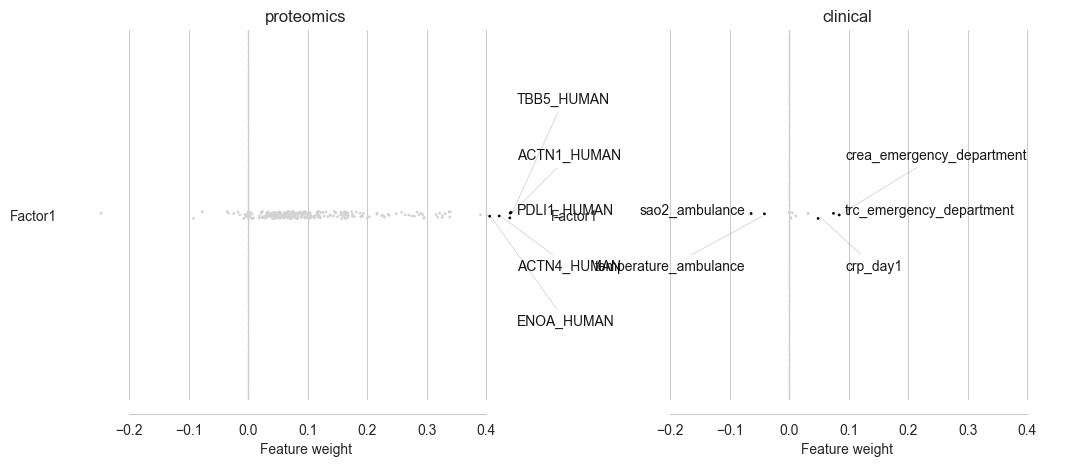

In [27]:
mofa.plot_weights(model, views=['proteomics', 'clinical'], factors=0, zero_line=True, ncols=2, label_size=10)

In [28]:
model.get_r2()

,Factor,View,Group,R2
0,Factor1,proteomics,group1,11.036073
1,Factor1,clinical,group1,1.637975
2,Factor2,proteomics,group1,4.962955
3,Factor2,clinical,group1,6.549929
4,Factor3,proteomics,group1,4.981304
5,Factor3,clinical,group1,5.176580
6,Factor4,proteomics,group1,8.991406
7,Factor4,clinical,group1,0.037766
8,Factor5,proteomics,group1,1.631948
9,Factor5,clinical,group1,4.761392


In [33]:
model.get_weights(
   #factors=[1],
    df=True
).sort_values("Factor4", ascending=False).head(20)

,Factor1,Factor2,Factor3,Factor4,Factor5,Factor6,Factor7,Factor8,Factor9,Factor10
TRY3_HUMAN,-0.077013,0.000372,-0.149518,2.958011,0.001436,0.009657,0.021312,-0.002079,-0.001659,0.000665
FUCO_HUMAN,0.096433,0.009379,-0.000337,0.102449,0.115212,0.044066,0.009449,0.082183,0.022678,-0.001943
syst_bp_ambulance,0.000840,-0.098426,-0.014808,0.009990,0.077395,-0.052492,-0.009481,0.001469,-0.023974,-0.000103
PHLD_HUMAN,-0.024454,-0.164752,-0.166992,0.008612,-0.024125,0.004619,-0.000479,0.037709,0.109260,0.000030
MA2A1_HUMAN,0.165953,0.007885,-0.011155,0.007721,0.047543,0.038984,-0.007123,0.137319,-0.033740,0.004278
FGL1_HUMAN,0.106434,0.142335,0.261470,0.007469,0.000536,-0.108854,-0.159928,0.098178,0.185625,-0.000224
TBB1_HUMAN,0.390674,-0.286303,0.142328,0.007387,0.028965,-0.006863,-0.105410,-0.348245,-0.021013,-0.005250
FETUA_HUMAN,-0.005106,-0.096407,-0.167199,0.007363,0.096632,0.042512,0.027594,-0.014623,0.045904,0.000292
HLAB_HUMAN,0.236833,0.095500,-0.083358,0.006558,0.026443,0.165366,-0.003801,-0.005760,-0.020566,0.000182
CO6A3_HUMAN,0.092313,0.141841,-0.103152,0.004973,-0.017455,-0.004247,-0.002758,0.000202,-0.000876,0.000329


In [34]:

X_mofa = mdata.obsm['X_mofa']

In [35]:
mofa_columns = []

for i in range(X_mofa.shape[1]):

    mofa_col = f"MOFA {i}"

    mofa_columns.append(mofa_col)

    clinical_data_train[mofa_col] = X_mofa[:, i]

In [36]:
df_estimator = DigitalFamilyBinary(n_neighbors=10, neighbor_metric="euclidean")

In [37]:
df_estimator.fit(clinical_data_train, features=mofa_columns)

In [38]:
clinical_data_train['Resp Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="resp_dysfunction", bootstrap=False)

clinical_data_train['Renal Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="renal_dysfunction", bootstrap=False)

clinical_data_train['Cardio Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="cardiovasc_dysfunction", bootstrap=False)

clinical_data_train['Liver Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="liver_dysfunction", bootstrap=False)

clinical_data_train['CNS Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="cns_dysfunction", bootstrap=False)

clinical_data_train['Coag Rate'] = df_estimator.predict(clinical_data_train, features=mofa_columns, target_column="coag_dysfunction", bootstrap=False)

In [39]:
display_columns = [
    "Resp Rate",
    "Renal Rate",
    "Cardio Rate",
    "Liver Rate",
    "CNS Rate",
    "Coag Rate",
]

In [40]:
import matplotlib.pyplot as plt
import networkx as nx

G = df_estimator.network_


positions = nx.forceatlas2_layout(
    G,
    max_iter=1000,
    seed=0,
    #strong_gravity=True,
    dissuade_hubs=True
)

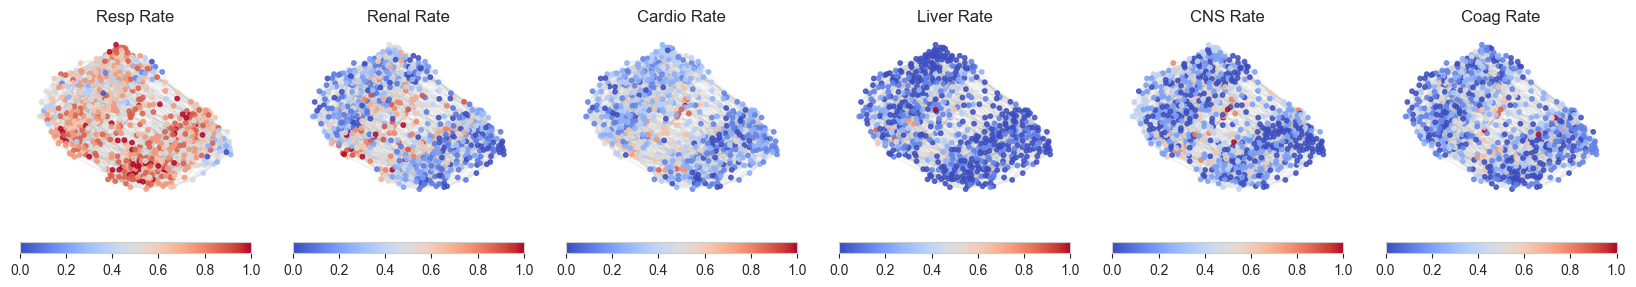

In [41]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=6
)

for i, col in enumerate(display_columns):

    # values = training_data[col].to_numpy()
    # cmap = plt.cm.coolwarm
    # norm = plt.Normalize(vmin=training_data[col].min(), vmax=training_data[col].max())
    # colors = cmap(norm(values))

    color_normalizer = MinMaxScaler((0, 1))

    values = MinMaxScaler().fit_transform(clinical_data_train[[col]])

    color_map = dict(zip(clinical_data_train.index, values))
    node_colors = [color_map[node] for node in G.nodes()]

    nx.draw_networkx_nodes(G, positions, node_size=10, node_color=node_colors, cmap="coolwarm", alpha=0.8, ax=axs[i])
    nx.draw_networkx_edges(G, positions, edge_color="gray", alpha=0.05, ax=axs[i])

    axs[i].axis("off")

    axs[i].set_title(col)

    sm = plt.cm.ScalarMappable(cmap="coolwarm")
    cbar = fig.colorbar(sm, ax=axs[i], orientation="horizontal")

    #cbar = fig.colorbar(ax=axs[i])

fig.set_size_inches((8.27 * 2, 3))
plt.tight_layout()

<Axes: >

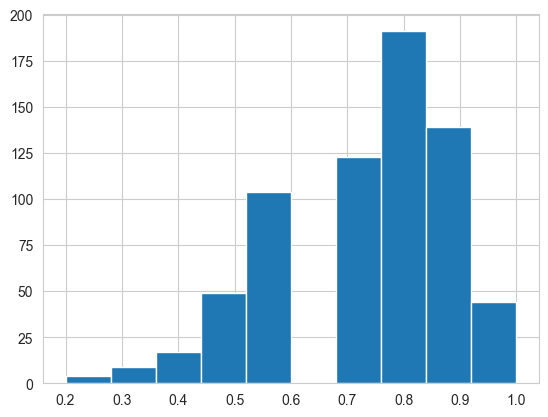

In [42]:
clinical_data_train['Resp Rate'].hist()

In [43]:
clinical_data_train[clinical_data_train['Liver Rate'] > clinical_data_train['Liver Rate'].mean()]

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,MOFA 6,MOFA 7,MOFA 8,MOFA 9,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate
0,0,SA_BOX_1-462_S1-C8_1_6848,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,...,2.059839,2.777192,0.996789,0.313154,0.5,0.1,0.4,0.2,0.1,0.2
2,2,SA_BOX_3-2442_S4-H8_1_5579,0.582753,2.075484,0.564982,-0.182072,0.000000,1.0,1.084859,-0.630818,...,-4.148676,0.110718,-0.788103,-0.273149,0.7,0.0,0.0,0.1,0.0,0.0
3,3,SA_BOX_2-1644_S2-A10_1_6960,-1.008986,0.483898,-0.784273,-0.434471,-0.992900,1.0,-0.183094,-0.026722,...,-0.799198,-1.576066,1.630445,2.490776,0.6,0.6,0.1,0.1,0.0,0.0
9,9,SA_BOX_11-710_S4-B7_1_6350,0.696449,0.116608,-0.087883,-0.362357,0.034848,1.0,0.109510,-0.253258,...,1.194874,-1.084585,3.248076,-0.887795,0.8,0.1,0.2,0.2,0.1,0.5
10,10,SA_BOX_4-2039_S5-A6_1_5653,1.037535,0.116608,-0.087883,-1.227725,-1.378306,2.0,-1.646117,0.760760,...,-2.213647,0.369064,1.111688,-0.495096,1.0,1.0,0.5,0.2,0.0,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,670,SA_BOX_7-719_S4-E10_1_5984,-0.213116,1.096046,-0.174932,1.620779,0.000000,1.0,-0.280629,-0.641606,...,2.718381,-0.311401,0.495811,-1.731295,0.6,0.2,0.1,0.2,0.1,0.2
671,671,SA_BOX_6-746_S2-E6_1_5853,0.923840,-1.352548,0.826128,0.250612,0.527311,1.0,1.279928,-0.544519,...,-1.968525,1.733542,2.975519,-1.691834,0.9,0.1,0.1,0.1,0.1,0.0
673,673,SA_BOX_6-236_S2-E9_1_5878,-0.099421,-1.107689,-0.958370,0.899639,0.000000,1.0,-0.085559,-0.339558,...,4.320342,-2.642665,1.048399,2.648328,0.8,0.5,0.1,0.3,0.0,0.1
675,675,SA_BOX_11-2056_S4-F8_1_6362,0.810144,1.096046,-0.740748,-0.542642,-0.714552,1.0,-1.255977,-0.350345,...,-0.688430,-0.094395,-0.407024,-2.538507,0.8,0.1,0.1,0.1,0.2,0.0


In [44]:
clinical_data_train[clinical_data_train['Liver Rate'] > 0]

,Unnamed: 0,injection,sao2_ambulance,resp_frequency_ambulance,heart_rate_ambulance,syst_bp_ambulance,map_ambulance,mental_status_ambulance,temperature_ambulance,crea_emergency_department,...,MOFA 6,MOFA 7,MOFA 8,MOFA 9,Resp Rate,Renal Rate,Cardio Rate,Liver Rate,CNS Rate,Coag Rate
0,0,SA_BOX_1-462_S1-C8_1_6848,-0.440508,-0.862829,0.347360,-0.182072,0.270374,1.0,0.694719,-0.555306,...,2.059839,2.777192,0.996789,0.313154,0.5,0.1,0.4,0.2,0.1,0.2
2,2,SA_BOX_3-2442_S4-H8_1_5579,0.582753,2.075484,0.564982,-0.182072,0.000000,1.0,1.084859,-0.630818,...,-4.148676,0.110718,-0.788103,-0.273149,0.7,0.0,0.0,0.1,0.0,0.0
3,3,SA_BOX_2-1644_S2-A10_1_6960,-1.008986,0.483898,-0.784273,-0.434471,-0.992900,1.0,-0.183094,-0.026722,...,-0.799198,-1.576066,1.630445,2.490776,0.6,0.6,0.1,0.1,0.0,0.0
9,9,SA_BOX_11-710_S4-B7_1_6350,0.696449,0.116608,-0.087883,-0.362357,0.034848,1.0,0.109510,-0.253258,...,1.194874,-1.084585,3.248076,-0.887795,0.8,0.1,0.2,0.2,0.1,0.5
10,10,SA_BOX_4-2039_S5-A6_1_5653,1.037535,0.116608,-0.087883,-1.227725,-1.378306,2.0,-1.646117,0.760760,...,-2.213647,0.369064,1.111688,-0.495096,1.0,1.0,0.5,0.2,0.0,0.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
670,670,SA_BOX_7-719_S4-E10_1_5984,-0.213116,1.096046,-0.174932,1.620779,0.000000,1.0,-0.280629,-0.641606,...,2.718381,-0.311401,0.495811,-1.731295,0.6,0.2,0.1,0.2,0.1,0.2
671,671,SA_BOX_6-746_S2-E6_1_5853,0.923840,-1.352548,0.826128,0.250612,0.527311,1.0,1.279928,-0.544519,...,-1.968525,1.733542,2.975519,-1.691834,0.9,0.1,0.1,0.1,0.1,0.0
673,673,SA_BOX_6-236_S2-E9_1_5878,-0.099421,-1.107689,-0.958370,0.899639,0.000000,1.0,-0.085559,-0.339558,...,4.320342,-2.642665,1.048399,2.648328,0.8,0.5,0.1,0.3,0.0,0.1
675,675,SA_BOX_11-2056_S4-F8_1_6362,0.810144,1.096046,-0.740748,-0.542642,-0.714552,1.0,-1.255977,-0.350345,...,-0.688430,-0.094395,-0.407024,-2.538507,0.8,0.1,0.1,0.1,0.2,0.0


In [57]:
clinical_data_train.to_csv(
    "organ_dysfunction_design_matrix.tsv",
    sep="\t",
    index=False
)